<a href="https://colab.research.google.com/github/Thrakrien/ann-ifes-studies/blob/main/IMDB_Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalando os pacotes do torch e do hf
!pip install -q transformers datasets torch accelerate

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from pathlib import Path
import pandas as pd
from tqdm.auto import tqdm
import torch

In [19]:
# !tar -xzvf /content/aclImdb_v1.tar.gz

In [3]:
def load_imdb_from_folders(base_dir, split="test"):

    base_path = Path(base_dir)
    split_path = base_path / split

    data = []

    for label_name, label_id in [("neg", 0), ("pos", 1)]:
        folder = split_path / label_name

        for file_path in folder.glob("*.txt"):
            text = file_path.read_text(encoding="utf-8", errors="ignore")

            data.append({
                "file_name": file_path.name,
                "text": text,
                "label": label_id,
                "label_name": "negative" if label_name == "neg" else "positive"
            })

    df = pd.DataFrame(data)

    return df

In [4]:
df_test = load_imdb_from_folders(
    base_dir="/content/aclImdb",
    split="test")

df_test.head()

,file_name,text,label,label_name
0,12342_1.txt,This is the worst movie I have ever seen in my...,0,negative
1,7521_1.txt,I was one of the many fools who were sapped ou...,0,negative
2,442_3.txt,I was a fan of the AMERICAN WEREWOLF IN LONDON...,0,negative
3,5570_2.txt,I only watched this because I saw a couple of ...,0,negative
4,2074_1.txt,"Like the other guy said It sux , you can count...",0,negative


In [5]:
df_test["label_name"].value_counts()

,count
label_name,
negative,12500
positive,12500


In [20]:
# sample_size = 1000

# df_sample = df_test.sample(
#     n=sample_size,
#     random_state=42
# ).reset_index(drop=True)

# df_sample.head()

In [12]:
device = 0 if torch.cuda.is_available() else -1

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device
)

print("Device usado:", "gpu" if device == 0 else "cpu")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Device usado: gpu


In [13]:
texts = df_test["text"].tolist()

outputs = sentiment_pipeline(
    texts,
    truncation=True,
    max_length=512,
    batch_size=32
)

In [14]:
df_test["predicted_label_hf"] = [out["label"] for out in outputs]
df_test["score"] = [out["score"] for out in outputs]

df_test["predicted_label_name"] = df_test["predicted_label_hf"].map({
    "NEGATIVE": "negative",
    "POSITIVE": "positive"
})

df_test.head()

,file_name,text,label,label_name,predicted_label_hf,score,predicted_label_name
0,12342_1.txt,This is the worst movie I have ever seen in my...,0,negative,NEGATIVE,0.999795,negative
1,7521_1.txt,I was one of the many fools who were sapped ou...,0,negative,NEGATIVE,0.985382,negative
2,442_3.txt,I was a fan of the AMERICAN WEREWOLF IN LONDON...,0,negative,NEGATIVE,0.998989,negative
3,5570_2.txt,I only watched this because I saw a couple of ...,0,negative,NEGATIVE,0.998948,negative
4,2074_1.txt,"Like the other guy said It sux , you can count...",0,negative,NEGATIVE,0.998399,negative


In [21]:
accuracy = accuracy_score(
    df_test["label_name"],
    df_test["predicted_label_name"]
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8907


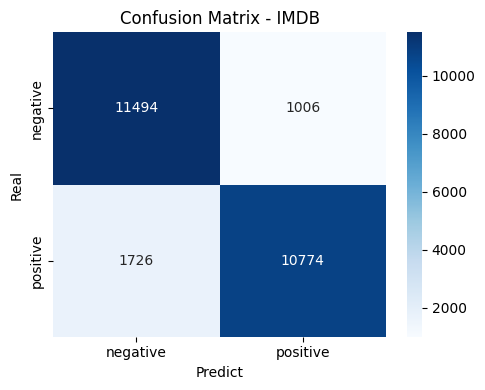

In [22]:
cm = confusion_matrix(
    df_test["label_name"],
    df_test["predicted_label_name"],
    labels=["negative", "positive"]
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"]
)

plt.xlabel("Predict")
plt.ylabel("Real")
plt.title("Confusion Matrix - IMDB")
plt.tight_layout()
plt.show()

In [25]:
!pwd

/content


In [29]:
import json
from pathlib import Path

notebook_path = "IMDB_Sentimental_Analysis.ipynb"  # troque pelo nome real do arquivo

with open(notebook_path, "r", encoding="utf-8") as f:
    notebook = json.load(f)

# Remove metadados problemáticos de widgets
if "widgets" in notebook.get("metadata", {}):
    del notebook["metadata"]["widgets"]

clean_path = notebook_path.replace(".ipynb", "_clean.ipynb")

with open(clean_path, "w", encoding="utf-8") as f:
    json.dump(notebook, f, ensure_ascii=False, indent=1)

print(f"Notebook limpo salvo em: {clean_path}")

FileNotFoundError: [Errno 2] No such file or directory: 'IMDB_Sentimental_Analysis.ipynb'